# 10 Notebook Modelling trimmed

In [23]:
import pandas as pd
import numpy as np
from pycaret.classification import *

## Loading data

In [24]:
# Load encoded feature matrices saved during feature engineering
X_train = pd.read_csv('../data/features/X_train_trimmed.csv')
X_test = pd.read_csv('../data/features/X_test_trimmed.csv')

# Load target vectors — squeeze converts single-column DataFrame to Series
y_train = pd.read_csv('../data/features/y_train_trimmed.csv').squeeze()
y_test = pd.read_csv('../data/features/y_test_trimmed.csv').squeeze()

print(f'X_train shape: {X_train.shape}')
print(f'X_test shape:  {X_test.shape}')
print(f'y_train distribution:\n{y_train.value_counts(normalize=True).round(3)}')
print(f'y_test distribution:\n{y_test.value_counts(normalize=True).round(3)}')

X_train shape: (234436, 33)
X_test shape:  (58609, 33)
y_train distribution:
citation_top_10_percent
0    0.82
1    0.18
Name: proportion, dtype: float64
y_test distribution:
citation_top_10_percent
0    0.82
1    0.18
Name: proportion, dtype: float64


## Combining train data for PyCaret

In [25]:
# PyCaret setup() requires a single DataFrame with features + target combined
# X_test and y_test are kept separate for final evaluation after modelling
train_data = X_train.copy()
train_data['target'] = y_train.values

print(f'Train data shape: {train_data.shape}')
print(f'Target distribution:\n{train_data["target"].value_counts()}')

Train data shape: (234436, 34)
Target distribution:
target
0    192194
1     42242
Name: count, dtype: int64


##  PyCaret setup

In [26]:
# Initialise PyCaret experiment
# - target: column to predict
# - test_data: holdout set — PyCaret will never touch this during training
# - fix_imbalance: applies SMOTE to training folds only to handle 82/18 class imbalance
# - session_id: random seed for reproducibility
# - index=False: resets index to RangeIndex to avoid duplicate index error
# - verbose: shows setup summary table
experiment = setup(
    data=train_data,
    target='target',
    test_data=pd.concat([X_test, y_test.rename('target')], axis=1).reset_index(drop=True),
    fix_imbalance=True,
    session_id=42,
    index=False,
    verbose=True
)

,Description,Value
0,Session id,42
1,Target,target
2,Target type,Binary
3,Original data shape,"(293045, 34)"
4,Transformed data shape,"(442997, 34)"
5,Transformed train set shape,"(384388, 34)"
6,Transformed test set shape,"(58609, 34)"
7,Numeric features,33
8,Preprocess,True
9,Imputation type,simple


In [27]:
print(X_train.isnull().sum().sum())

0


## Compare models

In [28]:
# Compare all available classification models
# metric: optimise ranking by F1 score — appropriate for imbalanced classification
# sort: rank models by F1
# n_select: keep top 5 models for further analysis
best_models = compare_models(
    sort='F1',
    n_select=5,
    verbose=True
)

,,
,,
Initiated,. . . . . . . . . . . . . . . . . .,02:09:26
Status,. . . . . . . . . . . . . . . . . .,Fitting 10 Folds
Estimator,. . . . . . . . . . . . . . . . . .,Logistic Regression


,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC,TT (Sec)


Processing:   0%|          | 0/73 [00:00<?, ?it/s]

KeyboardInterrupt: 

In [ ]:
from pycaret.classification import save_model

save_model(best_models[0], '../models/gbc_trimmed')
print("Saved: models/gbc_trimmed.pkl")

Transformation Pipeline and Model Successfully Saved
Saved: models/gbc_trimmed.pkl


## compare_models() Results — Trimmed Feature Set (31 features)

| Metric | First Model (30 feat) | Enriched (54 feat) | Trimmed (31 feat) |
|---|---|---|---|
| F1 | 0.54 | 0.53 | 0.54 |
| AUC | 0.84 | 0.84 | 0.84 |
| Recall | 0.61 | 0.52 | 0.59 |
| Precision | 0.49 | 0.53 | 0.50 |

### Interpretation

Trimming recovered recall from 0.52 → 0.59 and restored F1 to first model levels.
Removing correlated pairs and near-zero importance features reduced noise without 
losing discriminative power (AUC unchanged at 0.84).

GBC remains the best model on F1 and recall. AdaBoost shows the highest recall 
across all three runs (0.65) and will be compared against GBC after tuning.

### Decision

Tune GBC with `optimize='Recall'` as primary model.
Run `tune_model()` on AdaBoost as secondary comparison.

## SHAP analysis - GBC model

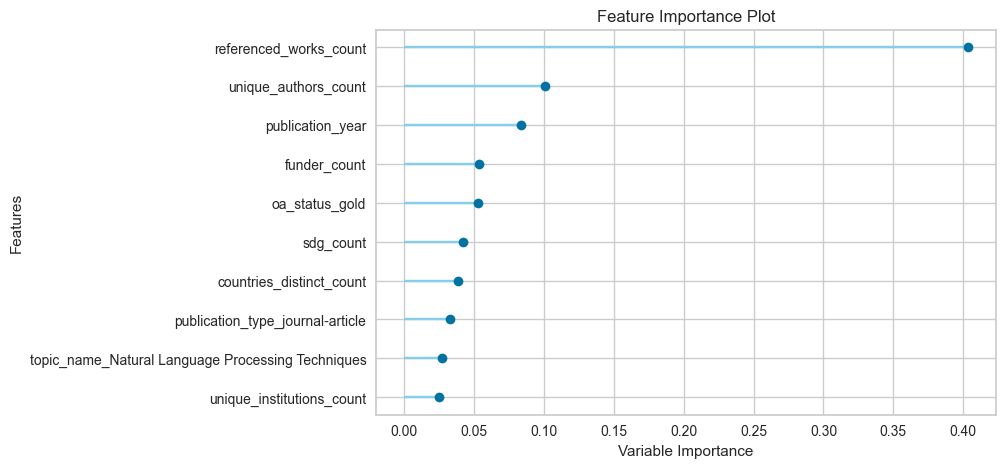

In [ ]:
# Plot feature importance for the best model
plot_model(best_models[0], plot='feature')

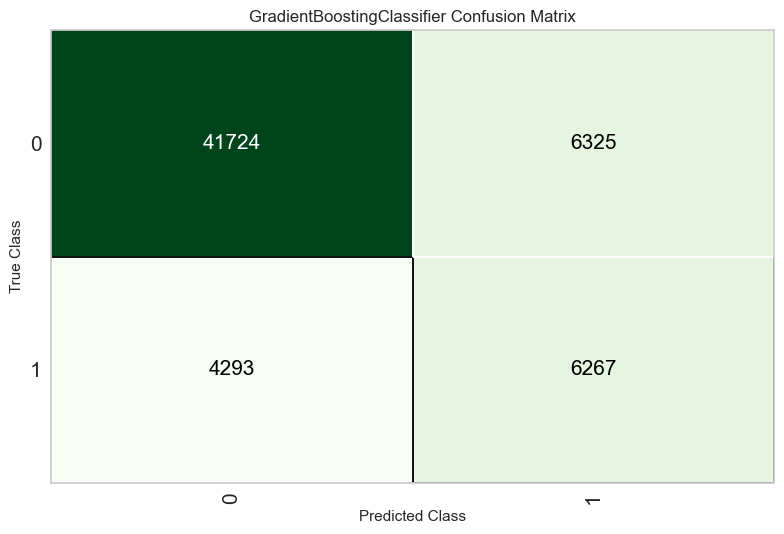

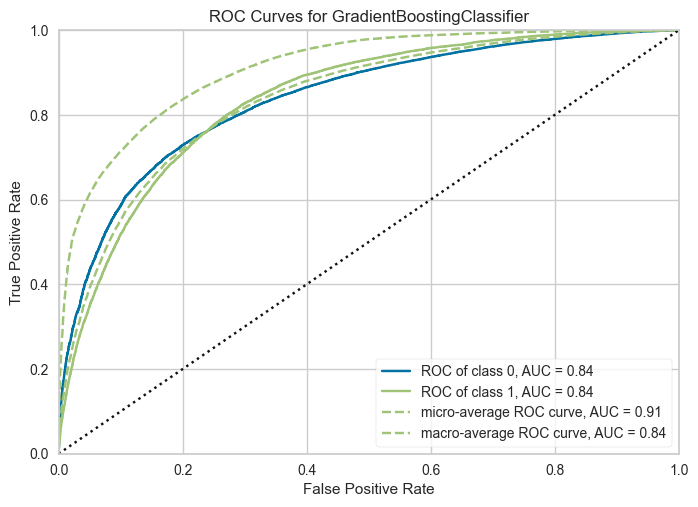

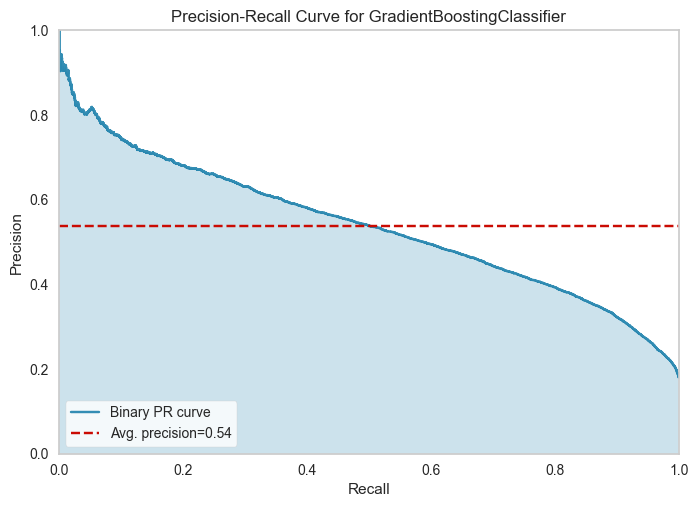

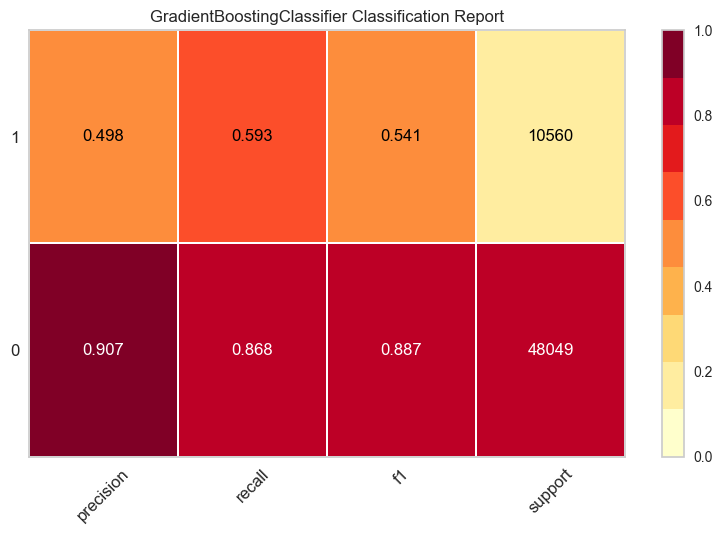

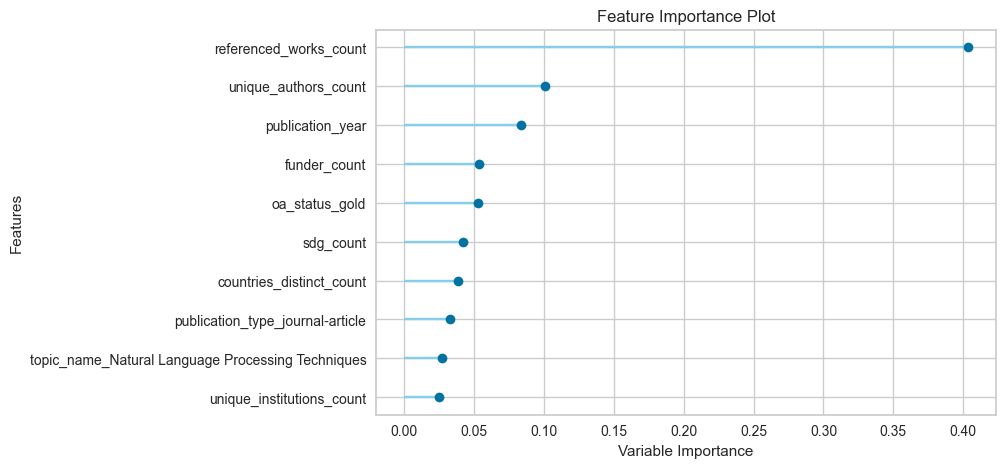

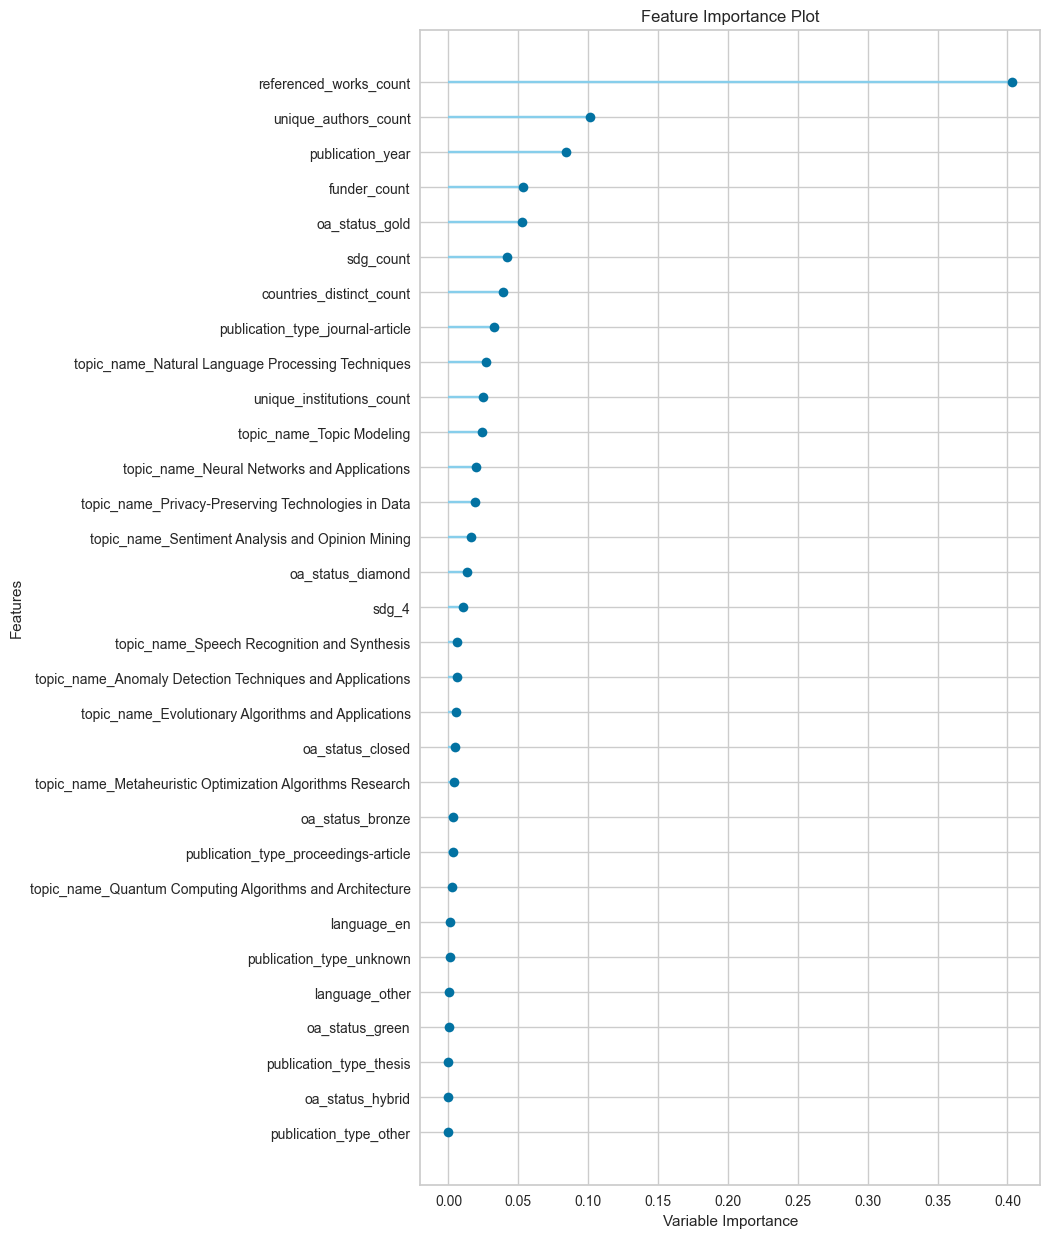

In [ ]:
# Confusion matrix — shows true/false positives and negatives
plot_model(best_models[0], plot='confusion_matrix')

# AUC-ROC curve
plot_model(best_models[0], plot='auc')

# Precision-Recall curve — more informative than AUC for imbalanced data
plot_model(best_models[0], plot='pr')

# Classification report — precision, recall, F1 per class
plot_model(best_models[0], plot='class_report')

# Feature importance
plot_model(best_models[0], plot='feature')

# Feature importance
plot_model(best_models[0], plot='feature_all')

## Model Evaluation — Trimmed GBC (Pre-Tuning)

### Results vs Previous Models

| Metric | First Model (30 feat) | Enriched (54 feat) | Trimmed (31 feat) |
|---|---|---|---|
| F1 | 0.54 | 0.53 | 0.54 |
| AUC | 0.84 | 0.84 | 0.84 |
| Recall | 0.61 | 0.53 | 0.59 |
| Precision | 0.49 | 0.53 | 0.50 |
| True Positives | 6,421 | 5,563 | 6,267 |
| False Negatives | 4,139 | 4,997 | 4,293 |

### Interpretation

Trimming recovered recall from 0.53 → 0.59 and restored F1 to first model levels.
AUC and PR AUC unchanged at 0.84 and 0.54 — no loss of discriminative power.
Feature importance is cleaner: `referenced_works_count` dominant (0.40),
`unique_authors_count` (0.10) and `publication_year` (0.09) as next strongest signals.

### Decision

Pre-tuning baseline is strong. Proceed with `tune_model(optimize='Recall')`
to push recall toward or beyond the first model's 0.61 ceiling.

## SHAP analysis - XGB model

In [ ]:
# Create and save XGBoost model
xgb = create_model('xgboost', session_id=42)
save_model(xgb, '../models/xgb_trimmed')
print("Saved: models/xgb_trimmed.pkl")

,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
Fold,,,,,,,
0,0.8476,0.8515,0.4205,0.6122,0.4985,0.4123,0.4224
1,0.8442,0.8501,0.4060,0.6001,0.4843,0.3966,0.4071
2,0.8481,0.8520,0.4084,0.6187,0.4920,0.4071,0.4192
3,0.8458,0.8494,0.4110,0.6061,0.4898,0.4029,0.4135
4,0.8449,0.8500,0.3943,0.6071,0.4781,0.3918,0.4044
5,0.8440,0.8480,0.4000,0.6010,0.4803,0.3929,0.4042
6,0.8470,0.8562,0.4060,0.6140,0.4888,0.4032,0.4151
7,0.8484,0.8541,0.4022,0.6230,0.4889,0.4047,0.4181
8,0.8491,0.8493,0.3987,0.6279,0.4877,0.4043,0.4187


Transformation Pipeline and Model Successfully Saved
Saved: models/xgb_trimmed.pkl


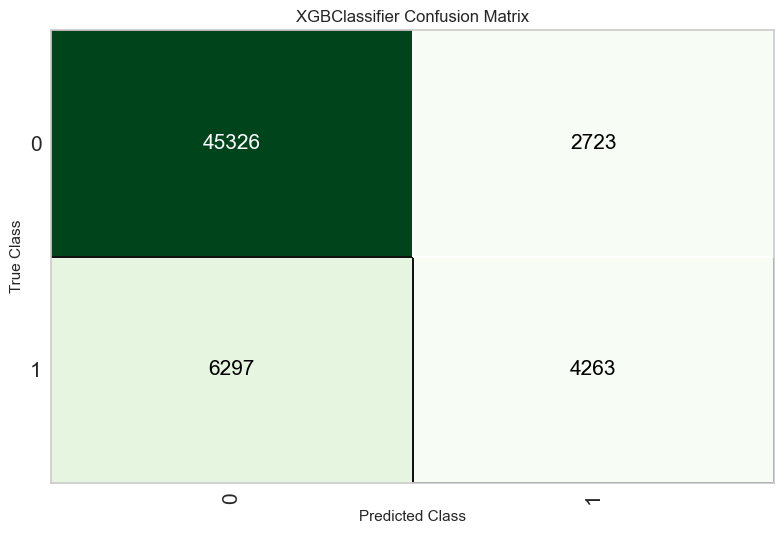

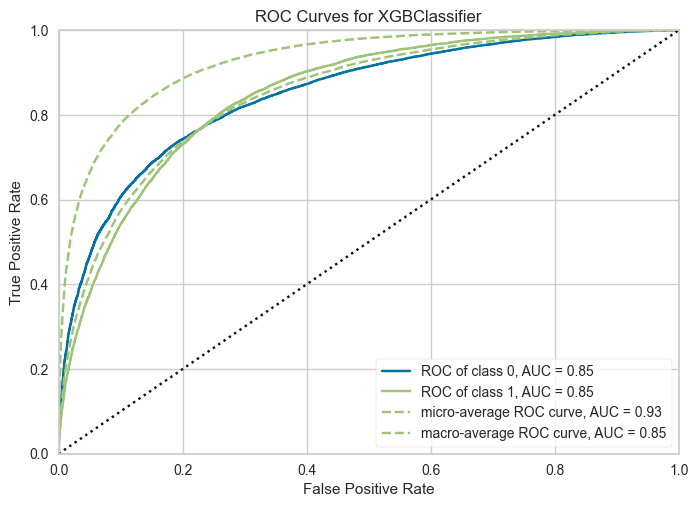

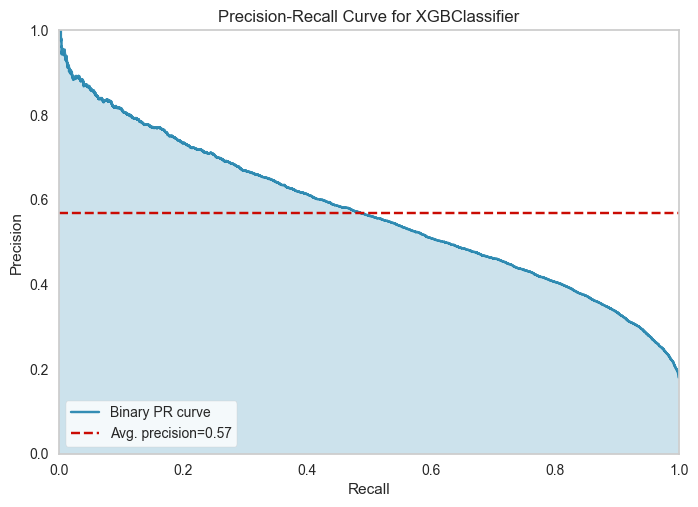

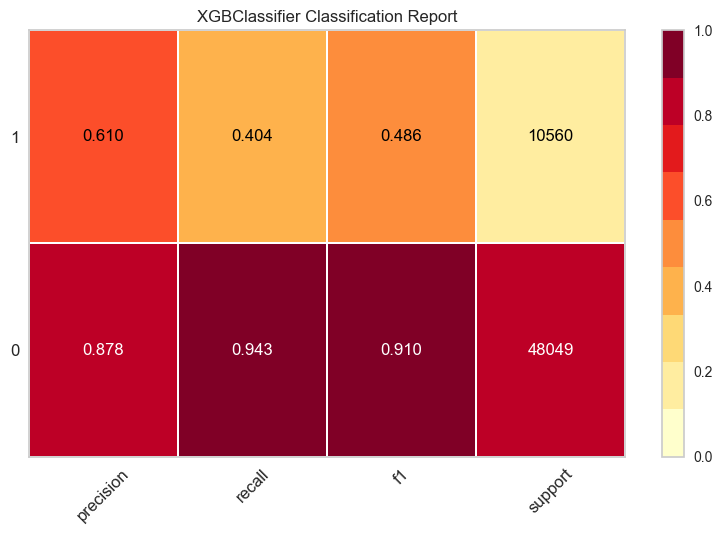

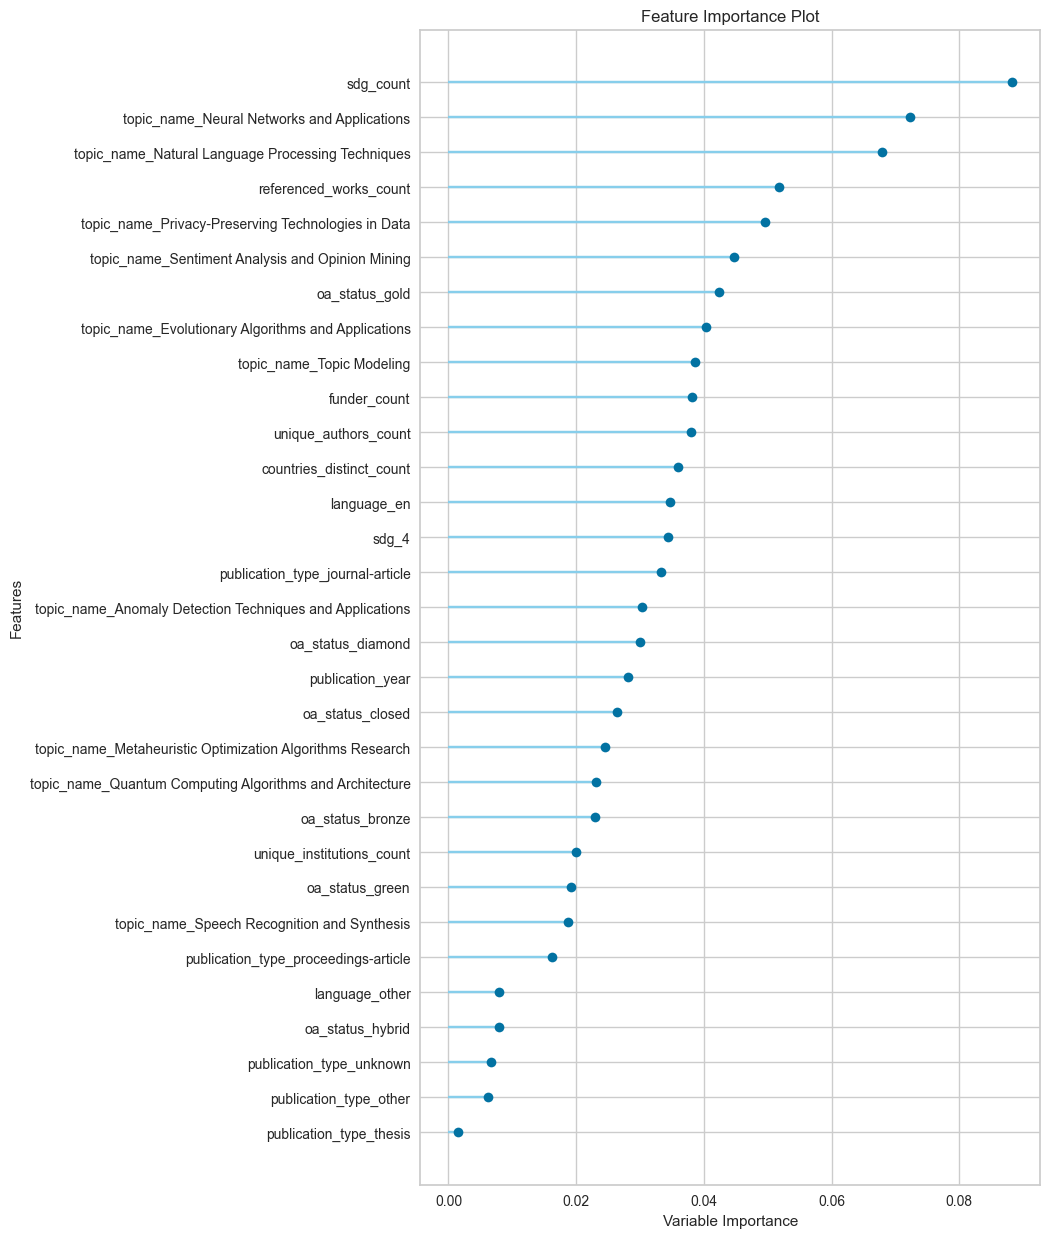

In [ ]:
plot_model(xgb, plot='confusion_matrix')
plot_model(xgb, plot='auc')
plot_model(xgb, plot='pr')
plot_model(xgb, plot='class_report')
plot_model(xgb, plot='feature_all')

## Model Evaluation — Trimmed XGBoost

| Metric | XGBoost Enriched | XGBoost Trimmed |
|---|---|---|
| F1 | 0.48 | 0.49 |
| AUC | 0.85 | 0.85 |
| Recall | 0.39 | 0.40 |
| Precision | 0.63 | 0.61 |
| True Positives | 4,077 | 4,263 |
| False Negatives | 6,483 | 6,297 |

Trimming produced negligible improvement. XGBoost remains precision-heavy and 
unsuitable for the publisher use case. Feature importance is still distorted —
`sdg_count` dominant despite ρ=0.04, `referenced_works_count` only 4th.

XGBoost ruled out. GBC taken forward to tuning.

## GBC model tunning

In [ ]:
# =============================================================================
# NOTEBOOK 10 | CELL — TUNE LIGHTGBM (fast validation run)
# =============================================================================

# LightGBM tuned as a fast proxy before committing to full GBC tuning
# - LightGBM is 10-20x faster than GBC on large datasets
# - compare_models() showed comparable AUC (0.85) and F1 (0.49)
# - n_iter=20: 20 random search iterations, ~15-20 mins
# - optimize='Recall': publisher use case priority
# - if recall improves meaningfully → run full GBC bayesian tuning overnight

lgbm = create_model('lightgbm', session_id=42)

tuned_lgbm = tune_model(
    lgbm,
    optimize       = 'Recall',
    n_iter         = 10,
    early_stopping = True,
    verbose        = True
)

,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
Fold,,,,,,,
0,0.8462,0.8501,0.4306,0.6025,0.5023,0.4143,0.4225
1,0.8443,0.8490,0.4141,0.5979,0.4893,0.4010,0.4104
2,0.8491,0.8525,0.4138,0.6223,0.4971,0.4125,0.4244
3,0.8452,0.8485,0.4266,0.5987,0.4982,0.4097,0.4179
4,0.8444,0.8494,0.4076,0.6006,0.4856,0.3979,0.4083
5,0.8436,0.8469,0.4187,0.5936,0.4910,0.4019,0.4104
6,0.8484,0.8561,0.4231,0.6154,0.5014,0.4156,0.4258
7,0.8447,0.8522,0.4115,0.6008,0.4884,0.4006,0.4106
8,0.8486,0.8498,0.4157,0.6190,0.4974,0.4123,0.4236


,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
Fold,,,,,,,
0,0.7057,0.8080,0.7786,0.3555,0.4881,0.3198,0.3683
1,0.7055,0.8041,0.7720,0.3543,0.4857,0.3171,0.3643
2,0.7130,0.8058,0.7772,0.3619,0.4939,0.3289,0.3757
3,0.7099,0.8015,0.7734,0.3586,0.4900,0.3235,0.3701
4,0.7116,0.8055,0.7808,0.3612,0.4939,0.3284,0.3761
5,0.6993,0.7987,0.7787,0.3498,0.4828,0.3115,0.3611
6,0.7085,0.8082,0.7824,0.3585,0.4917,0.3248,0.3735
7,0.7086,0.8039,0.7874,0.3592,0.4934,0.3268,0.3764
8,0.7020,0.8011,0.7753,0.3517,0.4839,0.3137,0.3622


Fitting 10 folds for each of 10 candidates, totalling 100 fits


In [ ]:


from pycaret.classification import load_model

gbc_trimmed = load_model('../models/gbc_trimmed')

tuned_gbc = tune_model(
    gbc_trimmed,
    optimize       = 'Recall',
    n_iter         = 10,
    fold           = 5,
    early_stopping = True,
    verbose        = True
)

Transformation Pipeline and Model Successfully Loaded


,,
,,
Initiated,. . . . . . . . . . . . . . . . . .,00:48:10
Status,. . . . . . . . . . . . . . . . . .,Searching Hyperparameters
Estimator,. . . . . . . . . . . . . . . . . .,Gradient Boosting Classifier


Fitting 5 folds for each of 10 candidates, totalling 50 fits


KeyboardInterrupt: 

In [ ]:
# =============================================================================
# NOTEBOOK 10 | CELL — TUNE GBC (quick run, random search)
# =============================================================================

# Quick tuning run to validate recall improvement before full bayesian search
# - search_library='scikit-learn' + random: no extra dependencies, fast
# - n_iter=10: 10 iterations, ~15-30 mins
# - optimize='Recall': publisher use case priority


from pycaret.classification import load_model

gbc_trimmed = load_model('../models/gbc_trimmed')

tuned_gbc = tune_model(
    gbc_trimmed,
    optimize       = 'Recall',
    n_iter         = 10,
    early_stopping = True,
    verbose        = True
)

Transformation Pipeline and Model Successfully Loaded


,,
,,
Initiated,. . . . . . . . . . . . . . . . . .,00:31:25
Status,. . . . . . . . . . . . . . . . . .,Searching Hyperparameters
Estimator,. . . . . . . . . . . . . . . . . .,Gradient Boosting Classifier


Fitting 10 folds for each of 10 candidates, totalling 100 fits


KeyboardInterrupt: 

In [ ]:
# =============================================================================
# NOTEBOOK 10 | CELL — LOAD SAVED GBC AND TUNE
# =============================================================================

# Tune GBC optimising for Recall — appropriate for publisher use case where
# catching high-impact papers matters more than precision
# - search_library='scikit-optimize' + search_algorithm='bayesian': learns from
#   previous iterations, more efficient than random search on large datasets
# - n_iter=50: 50 bayesian iterations, balance between thoroughness and runtime
# - early_stopping=True: halts if no improvement, saves time

from pycaret.classification import load_model

gbc_trimmed = load_model('../models/gbc_trimmed')

tuned_gbc = tune_model(
    gbc_trimmed,
    optimize         = 'Recall',
    n_iter           = 50,
    search_library   = 'scikit-optimize',
    search_algorithm = 'bayesian',
    early_stopping   = True,
    verbose          = True
)

Transformation Pipeline and Model Successfully Loaded


,,
,,
Initiated,. . . . . . . . . . . . . . . . . .,00:27:24
Status,. . . . . . . . . . . . . . . . . .,Searching Hyperparameters
Estimator,. . . . . . . . . . . . . . . . . .,Gradient Boosting Classifier


Fitting 10 folds for each of 1 candidates, totalling 10 fits


KeyboardInterrupt: 